# Full-Day Multi-Seed Test
**PoliMi GSOM Algorithmic Trading 2026**

Runs `OptimizedAgent` (loading `best_params.npy` if present, else the hard-coded
defaults) across **many market seeds** on the **full 17:30 trading day**, then
shows a per-seed PnL table, summary stats, and plots — all inline.

---
**How to use:** edit the seed list / settings in *Section 1*, then *Run All*.

## 0 · Imports

In [1]:
import os, sys, time

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from abides_core import abides as abides_run
from abides_markets.configs.rmsc04 import build_config
from abides_markets.utils import config_add_agents
from student_work.optimized_agent import OptimizedAgent, _PARAM_KEYS, _load_params

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 1 · Settings

In [2]:
SEEDS = [                                  # 30 different market seeds (none used in training)
    7777, 8888, 4242, 6060, 1717, 31337, 11, 2718, 8675309, 110,
    2, 3, 5, 13, 21, 34, 55, 89, 144, 233,
    314, 271, 161, 100, 500, 777, 1234, 4321, 9999, 50000,
]
END_TIME      = "17:30:00"   # full trading day
TICKER        = "ABM"
STARTING_CASH = 10_000_000   # cents

params = _load_params()
print("Agent params being tested:")
for k in _PARAM_KEYS:
    print(f"  {k:15s} = {params[k]:.4f}")

Agent params being tested:
  window          = 60.6261
  w1              = 2.8931
  w2              = 4.1267
  w3              = 0.8120
  threshold       = 1.8402
  order_size      = 10.4011
  max_position    = 533.2200


## 2 · Run one full day per seed

Background market is standard RMSC04 (MomentumAgents removed). No order logging
— we only need each agent's end-of-day mark-to-market PnL.

In [3]:
def run_one(seed):
    cfg = build_config(
        seed=seed, end_time=END_TIME, num_momentum_agents=0,
        log_orders=False, exchange_log_orders=False, book_logging=False,
        stdout_log_level="WARNING", starting_cash=STARTING_CASH,
    )
    base_id = len(cfg["agents"])
    agent = OptimizedAgent(
        id=base_id, name="OptAgent", type="OptimizedAgent", symbol=TICKER,
        starting_cash=STARTING_CASH,
        random_state=np.random.RandomState(seed=seed + 777),
        params=params, log_orders=False,
    )
    cfg = config_add_agents(cfg, [agent])
    end_state = abides_run.run(cfg)
    for a in end_state["agents"]:
        if a.id == base_id:
            pnl = a.mark_to_market(a.holdings) - a.starting_cash
            return pnl, a.holdings.get(TICKER, 0)
    return 0, 0


t0 = time.time()
rows = []
for i, s in enumerate(SEEDS, 1):
    pnl, pos = run_one(s)
    rows.append({"seed": s, "pnl_usd": pnl / 100, "eod_position": pos})
    print(f"  [{i:2d}/{len(SEEDS)}] seed {s:>8d}: "
          f"PnL ${pnl/100:>+12,.2f}")

df = pd.DataFrame(rows)
df["win"] = df["pnl_usd"] > 0
print(f"\nDone in {time.time() - t0:.1f}s")

  [ 1/30] seed     7777: PnL $     +223.41
  [ 2/30] seed     8888: PnL $     +257.02
  [ 3/30] seed     4242: PnL $     -436.73
  [ 4/30] seed     6060: PnL $     +694.02
  [ 5/30] seed     1717: PnL $     -273.46
  [ 6/30] seed    31337: PnL $     +883.00
  [ 7/30] seed       11: PnL $      +55.72
  [ 8/30] seed     2718: PnL $     -676.43
  [ 9/30] seed  8675309: PnL $     -517.04
  [10/30] seed      110: PnL $      +90.27
  [11/30] seed        2: PnL $     -657.48
  [12/30] seed        3: PnL $      +56.30
  [13/30] seed        5: PnL $     +841.10
  [14/30] seed       13: PnL $   +1,128.70
  [15/30] seed       21: PnL $     +950.73
  [16/30] seed       34: PnL $     +510.90
  [17/30] seed       55: PnL $   +1,109.60
  [18/30] seed       89: PnL $     +743.40
  [19/30] seed      144: PnL $     +652.23
  [20/30] seed      233: PnL $      -74.16
  [21/30] seed      314: PnL $   +1,049.80
  [22/30] seed      271: PnL $   -1,471.20
  [23/30] seed      161: PnL $   +1,099.57
  [24/30] s

## 3 · Per-seed results table

In [4]:
show = df.sort_values("pnl_usd", ascending=False).reset_index(drop=True)
styled = (
    show.style
    .format({"pnl_usd": "${:+,.2f}", "eod_position": "{:+d}"})
    .background_gradient(subset=["pnl_usd"], cmap="RdYlGn")
    .set_caption("Per-seed full-day PnL (sorted best → worst)")
)
styled

,seed,pnl_usd,eod_position,win
0,13,"$+1,128.70",+310,True
1,55,"$+1,109.60",-320,True
2,161,"$+1,099.57",+150,True
3,314,"$+1,049.80",+130,True
4,21,$+950.73,-403,True
5,31337,$+883.00,-130,True
6,5,$+841.10,-77,True
7,89,$+743.40,-120,True
8,6060,$+694.02,+113,True
9,144,$+652.23,+253,True


## 4 · Summary statistics

In [5]:
p = df["pnl_usd"]
summary = pd.Series({
    "n_seeds":    len(df),
    "win_rate":   f"{int(df['win'].sum())}/{len(df)}",
    "mean_pnl":   f"${p.mean():+,.2f}",
    "median_pnl": f"${p.median():+,.2f}",
    "std_pnl":    f"${p.std():,.2f}",
    "worst":      f"${p.min():+,.2f}",
    "best":       f"${p.max():+,.2f}",
    "sharpe_like": f"{p.mean() / (p.std() + 1e-9):.3f}",
})
summary.to_frame("value")

,value
n_seeds,30
win_rate,18/30
mean_pnl,$+100.21
median_pnl,$+91.17
std_pnl,$738.15
worst,"$-1,471.44"
best,"$+1,128.70"
sharpe_like,0.136


## 5 · Plots

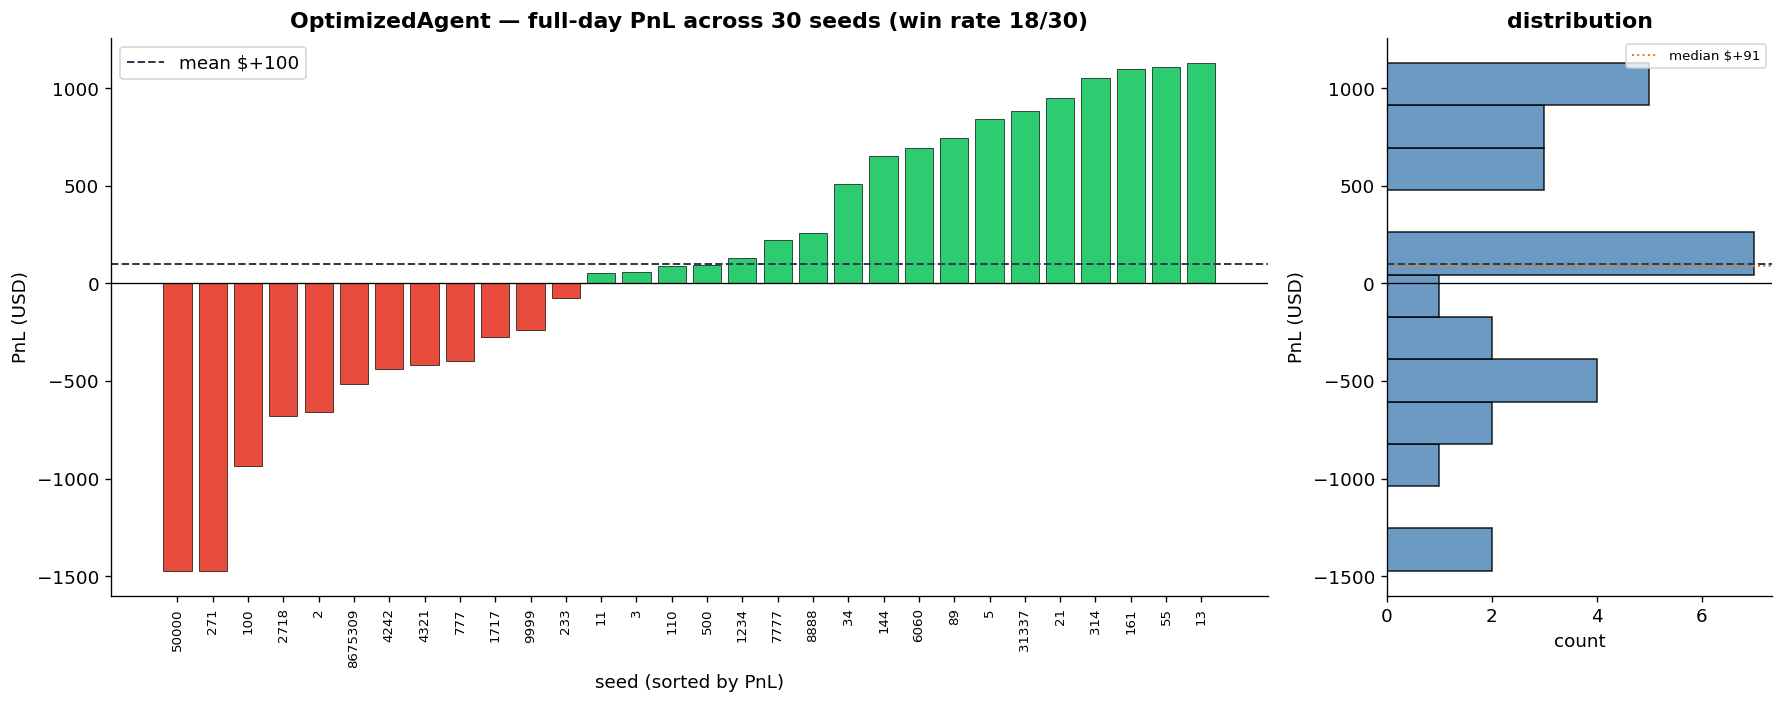

In [6]:
pnls = df["pnl_usd"].values
mean_d, med_d = pnls.mean(), np.median(pnls)
wins = int((pnls > 0).sum())

order = np.argsort(pnls)
labels = [str(df["seed"].values[i]) for i in order]
vals = pnls[order]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in vals]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [3, 1]}
)

# Panel 1: per-seed PnL bars (sorted)
ax1.bar(range(len(vals)), vals, color=colors, edgecolor="black", linewidth=0.4)
ax1.axhline(0, color="black", linewidth=0.8)
ax1.axhline(mean_d, color="#2c3e50", linestyle="--", linewidth=1.2,
            label=f"mean ${mean_d:+,.0f}")
ax1.set_xticks(range(len(vals)))
ax1.set_xticklabels(labels, rotation=90, fontsize=8)
ax1.set_xlabel("seed (sorted by PnL)")
ax1.set_ylabel("PnL (USD)")
ax1.set_title(f"OptimizedAgent — full-day PnL across {len(df)} seeds "
              f"(win rate {wins}/{len(df)})", fontweight="bold")
ax1.legend(loc="upper left")
ax1.spines[["top", "right"]].set_visible(False)

# Panel 2: distribution
ax2.hist(pnls, bins=12, color="steelblue", alpha=0.8,
         edgecolor="black", orientation="horizontal")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(mean_d, color="#2c3e50", linestyle="--", linewidth=1.2)
ax2.axhline(med_d, color="#e67e22", linestyle=":", linewidth=1.2,
            label=f"median ${med_d:+,.0f}")
ax2.set_xlabel("count")
ax2.set_ylabel("PnL (USD)")
ax2.set_title("distribution", fontweight="bold")
ax2.legend(loc="upper right", fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()